In [40]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from typing import List
from tqdm import tqdm
import random
import seaborn as sns


1.  Считать данные по ссылке (см выше)
2. Провести EDA  (разведочный анализ данных)
3.  сформировать набор данных для обучения
4. Разделить на train/test  (test - последняя неделя)
5. Сделать рекомендации:
5.1. Random
5.2. Popular
5.3. TopPopular ( personal popular + Popular)
5.4. Взвешенных Popular 

Метрика MAP@10

In [41]:
df_users = pd.read_csv('data_original/data_original/users.csv')
df_interactions = pd.read_csv('data_original/data_original/interactions.csv')
df_items = pd.read_csv('data_original/data_original/items.csv')

In [42]:
print(df_users.head(10))

   user_id        age        income sex  kids_flg
0   973171  age_25_34  income_60_90   М         1
1   962099  age_18_24  income_20_40   М         0
2  1047345  age_45_54  income_40_60   Ж         0
3   721985  age_45_54  income_20_40   Ж         0
4   704055  age_35_44  income_60_90   Ж         0
5  1037719  age_45_54  income_60_90   М         0
6   391756  age_25_34   income_0_20   М         0
7    15878  age_25_34  income_40_60   М         1
8   846063  age_35_44  income_40_60   Ж         1
9   401219  age_35_44  income_40_60   Ж         0


In [43]:
print(df_interactions.head(10))

   user_id  item_id last_watch_dt  total_dur  watched_pct
0   176549     9506    2021-05-11       4250         72.0
1   699317     1659    2021-05-29       8317        100.0
2   656683     7107    2021-05-09         10          0.0
3   864613     7638    2021-07-05      14483        100.0
4   964868     9506    2021-04-30       6725        100.0
5  1032142     6686    2021-05-13      11286        100.0
6  1016458      354    2021-08-14       1672         25.0
7   884009      693    2021-08-04        703         14.0
8   648682     1449    2021-06-13      26246         75.0
9   203219    13582    2021-08-22       6975        100.0


In [44]:
print(df_items.head(10))

   item_id content_type                                  title  \
0    10711         film                         Поговори с ней   
1     2508         film                            Голые перцы   
2    10716         film                       Тактическая сила   
3     7868         film                                 45 лет   
4    16268         film                   Все решает мгновение   
5      854         film                              Северо-Юг   
6     1468         film                        Марья-искусница   
7    11114         film  Принцесса Лебедь: Пират или принцесса   
8     9853         film                     Лабиринты прошлого   
9     8604         film                         Третья попытка   

                                          title_orig  release_year  \
0                                     Hable con ella        2002.0   
1                                       Search Party        2014.0   
2                                     Tactical Force        201

In [45]:
df_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15963 entries, 0 to 15962
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   item_id       15963 non-null  int64  
 1   content_type  15963 non-null  object 
 2   title         15963 non-null  object 
 3   title_orig    11218 non-null  object 
 4   release_year  15865 non-null  float64
 5   genres        15963 non-null  object 
 6   countries     15926 non-null  object 
 7   for_kids      566 non-null    float64
 8   age_rating    15961 non-null  float64
 9   studios       1065 non-null   object 
 10  directors     14454 non-null  object 
 11  actors        13344 non-null  object 
 12  description   15961 non-null  object 
 13  keywords      15540 non-null  object 
dtypes: float64(3), int64(1), object(10)
memory usage: 1.7+ MB


In [46]:
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476251 entries, 0 to 5476250
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   user_id        int64  
 1   item_id        int64  
 2   last_watch_dt  object 
 3   total_dur      int64  
 4   watched_pct    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 208.9+ MB


In [47]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840197 entries, 0 to 840196
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   840197 non-null  int64 
 1   age       826102 non-null  object
 2   income    825421 non-null  object
 3   sex       826366 non-null  object
 4   kids_flg  840197 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 32.1+ MB


In [48]:
print("\nItems Description:")
print(df_items.describe())

print("\nInteractions Description:")
print(df_interactions.describe())

print("\nUsers Description:")
print(df_users.describe())


Items Description:
            item_id  release_year    for_kids    age_rating
count  15963.000000  15865.000000  566.000000  15961.000000
mean    8268.453424   2007.932241    0.201413     12.945555
std     4773.841513     16.881118    0.401411      5.495998
min        0.000000   1897.000000    0.000000      0.000000
25%     4141.500000   2007.000000    0.000000     12.000000
50%     8266.000000   2014.000000    0.000000     16.000000
75%    12414.500000   2018.000000    0.000000     16.000000
max    16518.000000   2021.000000    1.000000     21.000000

Interactions Description:
            user_id       item_id     total_dur   watched_pct
count  5.476251e+06  5.476251e+06  5.476251e+06  5.475423e+06
mean   5.491159e+05  8.485860e+03  8.295490e+03  4.637400e+01
std    3.166077e+05  4.740762e+03  4.856799e+04  4.191853e+01
min    0.000000e+00  0.000000e+00  1.000000e+00  0.000000e+00
25%    2.750140e+05  4.326000e+03  3.710000e+02  4.000000e+00
50%    5.493640e+05  8.776000e+03  2.8980

In [49]:
data = df_interactions.merge(df_users, how='left').merge(df_items, on='item_id', how='left')
print("\nMerged Data:")
print(data.head())


Merged Data:
   user_id  item_id last_watch_dt  total_dur  watched_pct         age  \
0   176549     9506    2021-05-11       4250         72.0   age_35_44   
1   699317     1659    2021-05-29       8317        100.0   age_35_44   
2   656683     7107    2021-05-09         10          0.0   age_25_34   
3   864613     7638    2021-07-05      14483        100.0  age_65_inf   
4   964868     9506    2021-04-30       6725        100.0   age_25_34   

         income sex  kids_flg content_type  ... release_year  \
0  income_40_60   М       0.0         film  ...       2013.0   
1  income_40_60   М       0.0         film  ...       2014.0   
2  income_60_90   М       0.0       series  ...       2021.0   
3  income_20_40   Ж       0.0       series  ...       2018.0   
4  income_20_40   Ж       0.0         film  ...       2013.0   

                                      genres  countries for_kids age_rating  \
0           фэнтези, мультфильм, музыкальные        США      NaN        0.0   
1  м

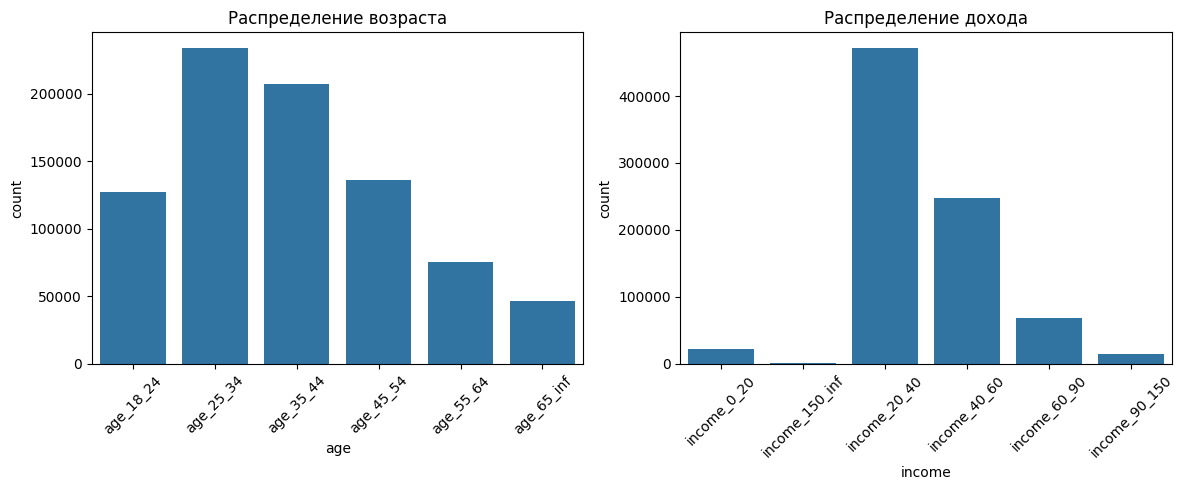

In [50]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_users, x='age', order=sorted(df_users['age'].dropna().unique()))
plt.title('Распределение возраста')
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
sns.countplot(data=df_users, x='income', order=sorted(df_users['income'].dropna().unique()))
plt.title('Распределение дохода')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

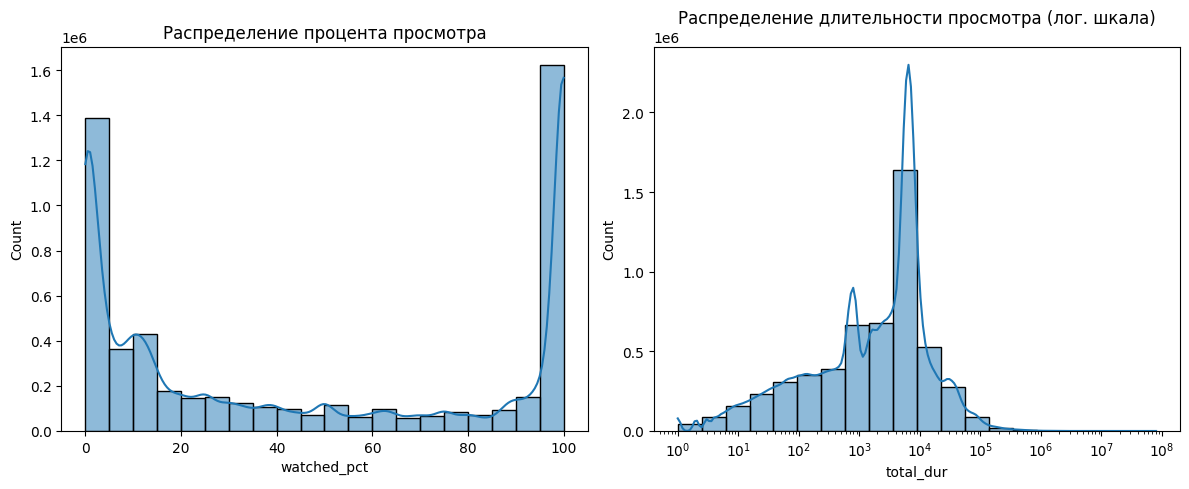

In [51]:
# Визуализация процента просмотра и длительности
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_interactions['watched_pct'], bins=20, kde=True)
plt.title('Распределение процента просмотра')
plt.subplot(1, 2, 2)
sns.histplot(df_interactions['total_dur'], bins=20, kde=True, log_scale=True)
plt.title('Распределение длительности просмотра (лог. шкала)')
plt.tight_layout()
plt.show()

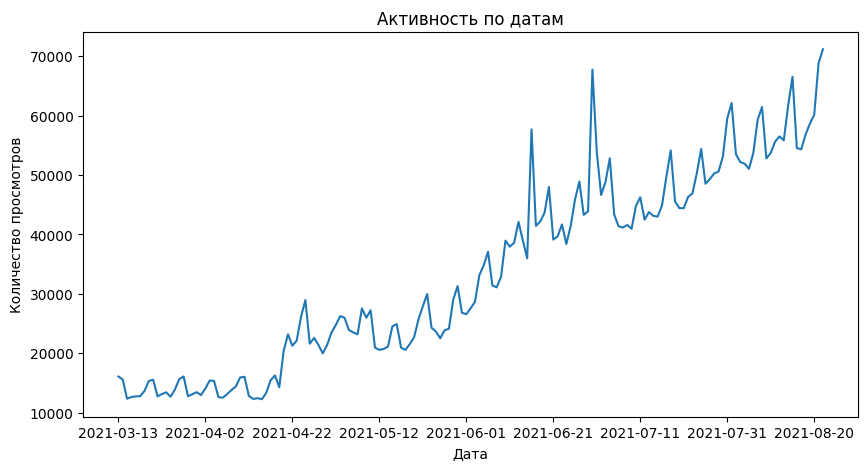

In [52]:
df_interactions['last_watch_dt'].value_counts().sort_index().plot(figsize=(10, 5), title='Активность по датам')
plt.xlabel('Дата')
plt.ylabel('Количество просмотров')
plt.show()

In [53]:
print("\n=== Анализ items1.csv ===")
print("Размер:", df_items.shape)
print("\nТипы данных:\n", df_items.dtypes)
print("\nПропуски:\n", df_items.isnull().sum())
print("\nОписательные статистики:\n", df_items.describe())


=== Анализ items1.csv ===
Размер: (15963, 14)

Типы данных:
 item_id           int64
content_type     object
title            object
title_orig       object
release_year    float64
genres           object
countries        object
for_kids        float64
age_rating      float64
studios          object
directors        object
actors           object
description      object
keywords         object
dtype: object

Пропуски:
 item_id             0
content_type        0
title               0
title_orig       4745
release_year       98
genres              0
countries          37
for_kids        15397
age_rating          2
studios         14898
directors        1509
actors           2619
description         2
keywords          423
dtype: int64

Описательные статистики:
             item_id  release_year    for_kids    age_rating
count  15963.000000  15865.000000  566.000000  15961.000000
mean    8268.453424   2007.932241    0.201413     12.945555
std     4773.841513     16.881118    0.401411   

In [54]:
print("\n=== Объединенный анализ ===")
merged = df_interactions.merge(df_users, on='user_id', how='left')
print("\nСредний % просмотра по возрасту:\n", merged.groupby('age')['watched_pct'].mean())
print("\nСредняя длительность по доходу:\n", merged.groupby('income')['total_dur'].mean())
print("\nСредний % просмотра по детям:\n", merged.groupby('kids_flg')['watched_pct'].mean())
print("\nСредний % просмотра по полу:\n", merged.groupby('sex')['watched_pct'].mean())


=== Объединенный анализ ===

Средний % просмотра по возрасту:
 age
age_18_24     46.118677
age_25_34     47.227033
age_35_44     47.506189
age_45_54     45.373630
age_55_64     42.954347
age_65_inf    40.072530
Name: watched_pct, dtype: float64

Средняя длительность по доходу:
 income
income_0_20        7168.509085
income_150_inf    11822.858161
income_20_40       7332.444716
income_40_60       7856.937506
income_60_90       8977.433367
income_90_150      9964.465286
Name: total_dur, dtype: float64

Средний % просмотра по детям:
 kids_flg
0.0    45.263070
1.0    47.907548
Name: watched_pct, dtype: float64

Средний % просмотра по полу:
 sex
Ж    46.503042
М    45.882190
Name: watched_pct, dtype: float64


In [55]:
numeric_cols = merged.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = merged[numeric_cols].corr()
print("\nКорреляции:\n", corr_matrix)


Корреляции:
               user_id   item_id  total_dur  watched_pct  kids_flg
user_id      1.000000  0.000665  -0.000708    -0.000900  0.004337
item_id      0.000665  1.000000   0.016484     0.027330  0.002600
total_dur   -0.000708  0.016484   1.000000     0.128353  0.004340
watched_pct -0.000900  0.027330   0.128353     1.000000  0.029681
kids_flg     0.004337  0.002600   0.004340     0.029681  1.000000


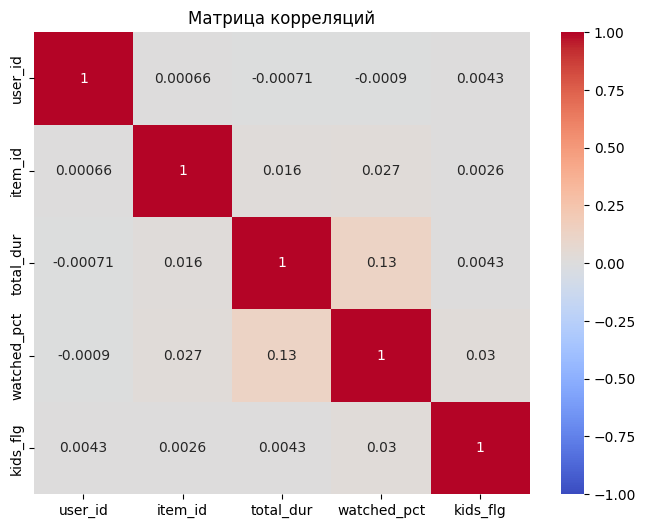

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций')
plt.show()

In [57]:
df_interactions = pd.read_csv('data_original/data_original/interactions.csv')
df_interactions['last_watch_dt'] = pd.to_datetime(df_interactions['last_watch_dt'], errors='coerce')  # Convert to datetime, coerce invalid to NaT

In [58]:
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5476251 entries, 0 to 5476250
Data columns (total 5 columns):
 #   Column         Dtype         
---  ------         -----         
 0   user_id        int64         
 1   item_id        int64         
 2   last_watch_dt  datetime64[ns]
 3   total_dur      int64         
 4   watched_pct    float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 208.9 MB


In [59]:
# Добавление нового столбца
df_interactions['completed'] = (df_interactions['watched_pct'] >= 80).astype(int)


3. Cформировать набор данных для обучения

In [60]:
k=10

test_size_days=10

dateColumnName = "last_watch_dt"
userColumnName = "user_id"
watchdPrcntColumnName = "watched_pct"
itemIdColumnName = "item_id"
totalDurColumnName = "total_dur"
reallyWatchedColumn = "completed"

In [61]:
from datetime import datetime, timedelta

# Тестовый промежуток времени равен 10 дней
max_date = df_interactions['last_watch_dt'].max()
test_start = max_date - timedelta(days=test_size_days)

In [62]:
# Разделение на тренировочный и тестовый
df_interactions_train = df_interactions[df_interactions['last_watch_dt'] < test_start]
df_interactions_test = df_interactions[df_interactions['last_watch_dt'] >= test_start]

In [63]:
df_interactions_train

,user_id,item_id,last_watch_dt,total_dur,watched_pct,completed
0,176549,9506,2021-05-11,4250,72.0,0
1,699317,1659,2021-05-29,8317,100.0,1
2,656683,7107,2021-05-09,10,0.0,0
3,864613,7638,2021-07-05,14483,100.0,1
4,964868,9506,2021-04-30,6725,100.0,1
...,...,...,...,...,...,...
5476243,497899,9629,2021-05-29,45,1.0,0
5476244,438585,7829,2021-08-02,6804,100.0,1
5476245,786732,4880,2021-05-12,753,0.0,0
5476247,546862,9673,2021-04-13,2308,49.0,0


In [64]:
df_interactions_test

,user_id,item_id,last_watch_dt,total_dur,watched_pct,completed
6,1016458,354,2021-08-14,1672,25.0,0
9,203219,13582,2021-08-22,6975,100.0,1
22,505244,15297,2021-08-15,15991,63.0,0
24,916352,12846,2021-08-12,1812,30.0,0
30,1057871,6208,2021-08-12,5033,95.0,1
...,...,...,...,...,...,...
5476204,1009040,13865,2021-08-13,56,1.0,0
5476222,1007900,9728,2021-08-12,416,6.0,0
5476246,648596,12225,2021-08-13,76,0.0,0
5476248,697262,15297,2021-08-20,18307,63.0,0


In [65]:
# Уникальные юзеры
train_unque_users = df_interactions_train['user_id'].unique()
test_unque_users = df_interactions_test['user_id'].unique()

test_unque_items = df_interactions_test['item_id'].unique()
train_unque_items = df_interactions_test['item_id'].unique()

all_items = df_interactions['item_id'].unique().tolist()


In [66]:
user_tests_content_interaction = df_interactions_test[((df_interactions_test['completed'] == True))]

In [67]:
user_tests_content_interaction_completed = df_interactions_test[((df_interactions_test['completed'] == True))]
user_train_content_interaction_completed = df_interactions_train[((df_interactions_train['completed'] == True))]

In [68]:
test_unique_items_completed = user_tests_content_interaction_completed['item_id'].unique()
train_unique_items_completed = user_train_content_interaction_completed['item_id'].unique()

In [69]:
# Сгруппировать items по пользователям
user_tests_content_interaction = df_interactions_test.groupby('user_id')['item_id'].unique().reset_index()

In [70]:
user_tests_content_interaction.columns = ['user_id', 'item_id']

In [71]:
user_tests_content_interaction

,user_id,item_id
0,1,"[3669, 10440]"
1,3,"[2025, 2722, 10240, 1896, 6208, 9438, 142, 965..."
2,9,[341]
3,12,[846]
4,14,[1204]
...,...,...
229996,1097536,[10440]
229997,1097540,[7160]
229998,1097544,"[13973, 16499, 15464, 1000]"
229999,1097545,[12360]


In [72]:
def precision(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # флаги: какие рекомендованные товары действительно куплены
    flags = np.isin(recommended, bought)

    return flags.sum() / len(recommended)


def precision_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(recommended, bought)

    return flags.sum() / k


def money_precision_at_k(recommended_list, bought_list, prices_recommended, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices = np.array(prices_recommended[:k])

    # флаги: куплен ли товар
    flags = np.isin(recommended, bought)

    # учитываем деньги
    return np.dot(flags, prices) / prices.sum()

In [73]:
def recall(recommended_list, bought_list):
    recommended = np.array(recommended_list)
    bought = np.array(bought_list)

    # какие купленные товары были среди рекомендованных
    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def recall_at_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    flags = np.isin(bought, recommended)

    return flags.sum() / len(bought)


def money_recall_at_k(recommended_list, bought_list, prices_recommended, prices_bought, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)
    prices_bought = np.array(prices_bought)

    # флаги: купленный товар есть в топ-k рекомендациях
    flags = np.isin(bought, recommended)

    # учитываем деньги (важны цены купленных товаров)
    return np.dot(flags, prices_bought) / prices_bought.sum()

In [74]:
def ap_k(recommended_list, bought_list, k=5):
    recommended = np.array(recommended_list[:k])
    bought = np.array(bought_list)

    # релевантность: рекомендованный товар куплен или нет
    flags = np.isin(recommended, bought)

    # если нет ни одного релевантного — AP = 0
    if flags.sum() == 0:
        return 0.0

    sum_precision = 0.0

    for i in range(k):
        if flags[i]:
            # precision@i+1 (на префиксе)
            precision_i = np.isin(recommended[:i+1], bought).sum() / (i + 1)
            sum_precision += precision_i

    # нормируем на число релевантных объектов в топ-k
    return sum_precision / flags.sum()

In [75]:
def get_user_items(df, user_id, user_col, item_col):
    result = df.loc[df[user_col] == user_id, item_col]
    return result.values[0] if not result.empty else None


def get_col_by_two_cols(df, first_col, second_col, value):
    return df.loc[df[first_col] == value, second_col]


def get_value_by_two_cols(df, first_col, second_col, value):
    result = get_col_by_two_cols(df, first_col, second_col, value)
    return result.values[0] if not result.empty else None

In [83]:
# получение списка взаимодействий юзера
def getUserItems(userItems, user_id):
  return userItems[(userItems[userColumnName] == user_id)][itemIdColumnName].values[0]

# получение значения из матрицы по двум столбцам
def getValueFromBy2Col(Items, first_column, second_column, first_c_id):
  return getColFromBy2Col(Items, first_column, second_column, first_c_id).values[0]

# получение значения из матрицы по двум столбцам
def getColFromBy2Col(Items, first_column, second_column, first_c_id):
  return Items[(Items[first_column] == first_c_id)][second_column]

Random

In [84]:
def getRandomRecommend(items, k=10):
  return np.random.choice(items, k)


In [85]:
def getFirstK(items, k=10):
  return items[:k]



In [ ]:
# items взять из тестового набора
def map_k(items, userContentInteractions, func, k=10): # func - функция для выбора из набора
    user_ids = userContentInteractions[userColumnName].tolist()
    result = [ap_k(func(items, k), getUserItems(userContentInteractions, i)) for i in user_ids]
    return np.average(result)

map_k_random = map_k(train_unique_items_completed, user_tests_content_interaction, getRandomRecommend, k)

print(map_k_random)

0.0005181136893607709


popular

In [110]:
# Получение популярных items по всем
def getPopularItems(df):
  items_content_interaction_Pop = df.groupby(itemIdColumnName)[watchdPrcntColumnName].unique().reset_index()
  items_content_interaction_Pop.columns = [itemIdColumnName, watchdPrcntColumnName]
  items_content_interaction_Pop[watchdPrcntColumnName] = items_content_interaction_Pop[watchdPrcntColumnName].apply(lambda x: len(np.array(x)))
  items_content_interaction_Pop.sort_values(by=watchdPrcntColumnName, ascending=False)
  return items_content_interaction_Pop[itemIdColumnName].unique()

items_train_content_interaction_Pop = df_interactions_train.groupby(itemIdColumnName)[watchdPrcntColumnName].unique().reset_index()

items_train_content_interaction_Pop.columns = [itemIdColumnName, watchdPrcntColumnName]

items_train_content_interaction_Pop[watchdPrcntColumnName] = items_train_content_interaction_Pop[watchdPrcntColumnName].apply(lambda x: len(np.array(x)))
items_train_content_interaction_Pop.sort_values(by=watchdPrcntColumnName, ascending=False)

list_popular_items = items_train_content_interaction_Pop[itemIdColumnName].unique()

map_k_Popular = map_k(list_popular_items, user_tests_content_interaction, getFirstK, k)

map_k_Popular

3.079696754941645e-05

In [118]:
def get_popular_items(df, item_id_col, watched_prcnt_col):
    """
    Возвращает список популярных элементов на основе количества уникальных
    значений просмотренного процента для каждого элемента.
    
    Args:
        df: DataFrame с данными
        item_id_col: Название колонки с идентификатором элемента
        watched_prcnt_col: Название колонки с процентом просмотра
        
    Returns:
        Массив уникальных ID элементов, отсортированных по популярности
    """
    # Группируем по элементам и получаем уникальные значения процента просмотра
    popular_items = (df.groupby(item_id_col)[watched_prcnt_col]
                     .unique()
                     .reset_index())
    
    # Переименовываем колонки
    popular_items.columns = [item_id_col, watched_prcnt_col]
    
    # Подсчитываем количество уникальных значений для каждого элемента
    popular_items[watched_prcnt_col] = popular_items[watched_prcnt_col].apply(
        lambda x: len(x)  # np.array не требуется, x уже является массивом
    )
    
    # Сортируем по убыванию популярности
    popular_items = popular_items.sort_values(
        by=watched_prcnt_col, 
        ascending=False
    )
    
    # Возвращаем список ID элементов в порядке популярности
    return popular_items[item_id_col].to_numpy()


# Получаем популярные элементы из тренировочных данных
popular_items_train = get_popular_items(
    df_interactions_train, 
    itemIdColumnName, 
    watchdPrcntColumnName
)

# Создаем отображение для k популярных элементов
map_k_popular = map_k(
    popular_items_train, 
    user_tests_content_interaction, 
    getFirstK, 
    k
)

print(map_k_popular)

0.025397184263450057


0.163311222318357

In [ ]:
# test_users

NameError: name 'test_users' is not defined

In [ ]:
# test_user_unique = df_interactions_test.groupby('user_id')['item_id'].unique().reset_index()

In [ ]:
# test_user_unique.columns = ['user_id', 'item_id']

In [ ]:
test_user_unique.head()

,user_id,item_id
0,1,"[3669, 10440]"
1,3,"[2025, 2722, 10240, 1896, 6208, 9438, 142, 965..."
2,9,[341]
3,12,[846]
4,14,[1204]


In [ ]:
# история из train
user_history = df_interactions_train.groupby('user_id')['item_id'].apply(set).to_dict()


In [ ]:
user_history

{0: {6006, 7102, 9728, 12192, 14359, 15297},
 2: {242,
  274,
  334,
  383,
  561,
  2025,
  2954,
  2956,
  3541,
  3594,
  3628,
  4024,
  4417,
  4436,
  4475,
  5693,
  5819,
  5894,
  6155,
  6774,
  6825,
  7106,
  7210,
  7571,
  7921,
  8482,
  8936,
  9164,
  9342,
  9506,
  10119,
  10636,
  10770,
  11018,
  11539,
  11577,
  11689,
  12449,
  12743,
  12841,
  12965,
  13159,
  13377,
  13867,
  13941,
  15196,
  15266,
  16029,
  16166},
 3: {1418,
  2220,
  2657,
  3475,
  3734,
  4151,
  4436,
  4880,
  8252,
  8581,
  8801,
  9550,
  9728,
  10440,
  10464,
  11790,
  12192,
  13789,
  13849,
  15719,
  16406},
 4: {4700, 6317},
 5: {632,
  2685,
  3145,
  4179,
  4719,
  5115,
  5651,
  6167,
  6445,
  7043,
  7825,
  8450,
  10848,
  11437,
  12466,
  14397,
  15890},
 7: {8710},
 8: {6809},
 9: {142, 2657, 3076, 3734, 4151, 9728, 9996, 10440, 13865, 15297},
 10: {1660, 10464, 13865},
 11: {2802,
  3787,
  4740,
  6809,
  7946,
  10125,
  10455,
  10788,
  12192,
  12

In [ ]:
# random_items = np.random.choice(df_interactions['item_id'], size=10, replace=False)
# random_items

In [ ]:
def get_random_recommendations(users, all_items, k=10):
    recs = {}
    for u in users:
        recs[u] = random.sample(all_items, k=min(k, len(all_items)))
    return recs

In [ ]:

def precision_at_k(recommended_list:np.ndarray, bought_list:np.ndarray, k:int)->float:
    
    recommended_list = recommended_list[:k]
    
    flags = np.isin(bought_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    
    return precision

In [ ]:
def ap_k(recommended_list:np.ndarray, bought_list:np.ndarray , k:int)->float:
    
    flags = np.isin(recommended_list, bought_list)
    
    if sum(flags) == 0:
        return 0.0
    
    sum_ = 0
    for i in range(0, k-1):
        if flags[i] == True:
            p_k = precision_at_k(recommended_list, bought_list, k=i+1)
            sum_ += p_k
            
    result = sum_ / sum(flags)
    
    return result

In [ ]:
def apk(actual, predicted, k=10):
    if len(predicted) > k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i+1.0)

    if not actual:
        return 0.0

    return score / min(len(actual), k)

In [ ]:
def mapk(actual, predicted, k=10):
    return np.mean([apk(a, predicted[u], k) for u, a in actual.items()])

In [ ]:
test_data = df_interactions_train[df_interactions_train['completed'] == True]

In [ ]:
actual = {}
for row in test_data.itertuples():
    if row.user_id not in actual:
        actual[row.user_id] = []
    actual[row.user_id].append(row.item_id)

In [ ]:
test_users = list(actual.keys())
test_users

[699317,
 864613,
 964868,
 1032142,
 988709,
 5324,
 15607,
 927973,
 896751,
 931816,
 841859,
 81786,
 1068939,
 158012,
 21723,
 568405,
 474544,
 311805,
 897955,
 580093,
 496279,
 750995,
 261118,
 820464,
 810825,
 934110,
 1022922,
 312347,
 230992,
 980485,
 585751,
 1073809,
 1058641,
 558890,
 802134,
 570761,
 312670,
 614443,
 614119,
 698174,
 69474,
 538575,
 611200,
 272325,
 375013,
 231634,
 1003443,
 141072,
 152853,
 179618,
 196721,
 98854,
 827032,
 59968,
 951289,
 713676,
 983199,
 907474,
 468941,
 339681,
 322182,
 134216,
 144129,
 216439,
 843274,
 858062,
 14246,
 946792,
 640016,
 1093823,
 51111,
 84682,
 174320,
 574539,
 588619,
 926736,
 284603,
 539950,
 752541,
 401866,
 247633,
 393684,
 968396,
 779186,
 1073233,
 599715,
 159613,
 992776,
 271492,
 306633,
 367775,
 611447,
 143940,
 221746,
 780668,
 173868,
 146665,
 382599,
 774286,
 969866,
 305598,
 710187,
 758443,
 778739,
 1023844,
 785146,
 275252,
 1085141,
 2152,
 383077,
 1042200,
 54

In [ ]:
predicted = get_random_recommendations(test_users, all_items, k=10)
predicted

{699317: [7718, 9553, 12745, 13131, 5294, 650, 7713, 15035, 4497, 16215],
 864613: [798, 15556, 333, 8735, 12345, 3575, 5289, 11148, 16209, 2222],
 964868: [14404, 1997, 9917, 561, 6653, 4089, 5752, 4435, 6712, 3787],
 1032142: [8346, 11443, 5553, 11204, 439, 5835, 4169, 15124, 3283, 62],
 988709: [671, 5769, 13803, 9017, 3734, 12545, 2935, 3613, 10544, 15974],
 5324: [6584, 3378, 5470, 6116, 9705, 13481, 4918, 7512, 2031, 4362],
 15607: [3142, 10546, 11141, 7285, 2907, 1551, 10721, 9745, 11628, 11567],
 927973: [38, 10998, 12780, 7581, 14302, 16484, 13239, 2384, 2336, 6251],
 896751: [2807, 5655, 5702, 1239, 10752, 14185, 7036, 15919, 5664, 6963],
 931816: [1938, 4013, 16437, 6613, 11890, 14272, 13088, 6323, 598, 4998],
 841859: [5938, 3864, 11418, 16068, 2256, 1650, 15723, 14093, 5600, 6000],
 81786: [11607, 15721, 12456, 15293, 9956, 6987, 2824, 9135, 8113, 7191],
 1068939: [1088, 14481, 11166, 15876, 12234, 6592, 11941, 3046, 16, 8355],
 158012: [11828, 14813, 31, 13741, 3735, 7986

random

In [ ]:
map10 = mapk(actual, predicted, k=10)
map10

np.float64(0.00021736080673930128)

popular


In [ ]:
popularity = df_interactions_train.groupby('item_id').size().sort_values(ascending=False)

In [ ]:
popular_items = list(popularity.index)

def get_popular_recommendations(users, popular_items, k=10):

    recs = {}
    for u in users:
        recs[u] = popular_items[:k]
    return recs

In [ ]:
test_data1 = df_interactions_train[df_interactions_train['completed'] == True]

# Словарь: user_id -> список релевантных item_id
actual = {}
for row in test_data1.itertuples():
    if row.user_id not in actual:
        actual[row.user_id] = []
    actual[row.user_id].append(row.item_id)


In [ ]:
predicted = get_popular_recommendations(train_users, popular_items, k=10)


popular

In [ ]:
map10_popular = mapk(actual, predicted, k=10)
map10_popular

np.float64(0.16177262569788747)

In [ ]:
def get_popular_recomendations(popular_items :np.ndarray,k :int)->np.ndarray:
    return np.random.choice(popular_items[:k], k, replace=False)

In [ ]:
def popular_map_k(interactions:pd.DataFrame, k:int)->float:
    popular_items = interactions.groupby('item_id')['completed'].apply(np.sum).sort_values(ascending=False)
    popular_items = popular_items.index

    aps = [
        ap_k(get_popular_recomendations(popular_items,k),bought_list=usr_items.unique(),k=k) 
        for uid,usr_items in interactions.groupby('user_id')['item_id']
        ]

    return np.mean(aps)



In [ ]:
popular_map10 = popular_map_k(df_interactions_train,k=10)
popular_map10

np.float64(0.18886289976104167)

Top popular